### Subtask 1.1: Data Acquisition and Train-Test Split

**Concept:** Load the Titanic dataset, select useful passenger features, encode categorical variables, handle missing values, and partition the dataset into training and test sets using stratification.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load Titanic dataset from public CSV repository
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("Titanic Dataset Shape:", titanic_df.shape)
print("\nMissing Values:")
print(titanic_df.isnull().sum())

# Select useful features
titanic_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
titanic_df = titanic_df[titanic_features + ['Survived']].copy()

# Handle missing values
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

# Encode categorical features
titanic_df = pd.get_dummies(
    titanic_df,
    columns=['Sex', 'Embarked'],
    drop_first=True,
    dtype=int
)

X_titanic = titanic_df.drop('Survived', axis=1)
y_titanic = titanic_df['Survived']

# Split into 80% train and 20% test partition
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

print("\nTitanic Classification Training Set Shape:", X_train_t.shape)
print("Titanic Classification Test Set Shape:", X_test_t.shape)


Titanic Dataset Shape: (891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Titanic Classification Training Set Shape: (712, 8)
Titanic Classification Test Set Shape: (179, 8)


### Subtask 1.2: Constructing the Decision Tree Classifier

**Concept:** Train a Decision Tree Classifier with maximum depth regularization and evaluate its classification performance.


In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train Decision Tree Classifier
tree_titanic = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_titanic.fit(X_train_t, y_train_t)

# Predict and evaluate
tree_titanic_preds = tree_titanic.predict(X_test_t)
tree_titanic_accuracy = accuracy_score(y_test_t, tree_titanic_preds)

print(f"Decision Tree Classifier Test Accuracy: {tree_titanic_accuracy * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(
    y_test_t,
    tree_titanic_preds,
    target_names=['Did Not Survive (0)', 'Survived (1)']
))


Decision Tree Classifier Test Accuracy: 78.77%

--- Classification Report ---
                     precision    recall  f1-score   support

Did Not Survive (0)       0.77      0.94      0.84       110
       Survived (1)       0.84      0.55      0.67        69

           accuracy                           0.79       179
          macro avg       0.81      0.74      0.76       179
       weighted avg       0.80      0.79      0.78       179



### Subtask 1.3: Constructing Ensemble and Boosting Classifiers

**Concept:** Apply Random Forest, Voting, AdaBoost, and Gradient Boosting classifiers to the Titanic dataset.


In [3]:
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Random Forest Classifier
rf_titanic = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_titanic.fit(X_train_t, y_train_t)

rf_titanic_preds = rf_titanic.predict(X_test_t)
rf_titanic_accuracy = accuracy_score(y_test_t, rf_titanic_preds)

print(f"Random Forest Classifier Test Accuracy: {rf_titanic_accuracy * 100:.2f}%")

# Voting Classifier
titanic_estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

voting_titanic = VotingClassifier(
    estimators=titanic_estimators,
    voting='soft',
    n_jobs=-1
)
voting_titanic.fit(X_train_t, y_train_t)

voting_titanic_preds = voting_titanic.predict(X_test_t)
voting_titanic_accuracy = accuracy_score(y_test_t, voting_titanic_preds)

print(f"Voting Classifier Test Accuracy: {voting_titanic_accuracy * 100:.2f}%")

# AdaBoost Classifier
adaboost_titanic = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)
adaboost_titanic.fit(X_train_t, y_train_t)

ada_titanic_preds = adaboost_titanic.predict(X_test_t)
ada_titanic_accuracy = accuracy_score(y_test_t, ada_titanic_preds)

print(f"AdaBoost Classifier Test Accuracy: {ada_titanic_accuracy * 100:.2f}%")

# Gradient Boosting Classifier
gb_titanic = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)
gb_titanic.fit(X_train_t, y_train_t)

gb_titanic_preds = gb_titanic.predict(X_test_t)
gb_titanic_accuracy = accuracy_score(y_test_t, gb_titanic_preds)

print(f"Gradient Boosting Classifier Test Accuracy: {gb_titanic_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 81.56%
Voting Classifier Test Accuracy: 77.65%
AdaBoost Classifier Test Accuracy: 78.21%
Gradient Boosting Classifier Test Accuracy: 79.89%


### Subtask 1.4: Classification Performance Comparison

**Concept:** Compare the test accuracies of the Decision Tree, Random Forest, Voting, AdaBoost, and Gradient Boosting classifiers.


In [4]:
titanic_results = pd.DataFrame({
    'Classification Technique': [
        'Decision Tree',
        'Random Forest',
        'Voting Classifier (Soft)',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'Test Accuracy (%)': [
        tree_titanic_accuracy * 100,
        rf_titanic_accuracy * 100,
        voting_titanic_accuracy * 100,
        ada_titanic_accuracy * 100,
        gb_titanic_accuracy * 100
    ]
}).sort_values(by='Test Accuracy (%)', ascending=False)

print("--- Titanic Classification Performance ---")
print(titanic_results.to_string(index=False))


--- Titanic Classification Performance ---
Classification Technique  Test Accuracy (%)
           Random Forest          81.564246
       Gradient Boosting          79.888268
           Decision Tree          78.770950
                AdaBoost          78.212291
Voting Classifier (Soft)          77.653631


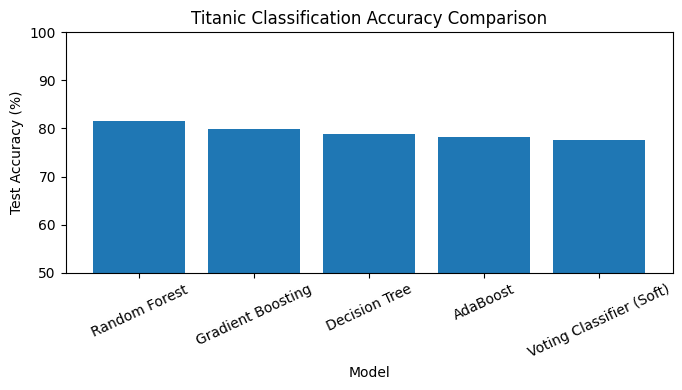

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(
    titanic_results['Classification Technique'],
    titanic_results['Test Accuracy (%)']
)
plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Titanic Classification Accuracy Comparison")
plt.xticks(rotation=25)
plt.ylim(50, 100)
plt.tight_layout()
plt.show()


## Task 2: Regression on California Housing Dataset

**Objective:** Predict the median house value using the California Housing dataset.

Models used:
- Decision Tree Regressor
- Random Forest Regressor
- Voting Regressor
- AdaBoost Regressor
- Gradient Boosting Regressor


### Subtask 2.1: Data Acquisition, Scaling and Train-Test Split

**Concept:** Load the California Housing dataset, separate features and target, standardize the feature space, and create training and testing partitions.


In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load California Housing dataset
california = fetch_california_housing(as_frame=True)

california_df = california.frame.copy()

print("California Housing Dataset Shape:", california_df.shape)
print("\nFeature Names:")
print(california.feature_names)

print("\nMissing Values:")
print(california_df.isnull().sum())

X_california = california.data
y_california = california.target

# Train-test split
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_california,
    y_california,
    test_size=0.20,
    random_state=42
)

# Standardize features, following the In-Lab regression workflow
scaler_cal = StandardScaler()
X_train_cal_scaled = scaler_cal.fit_transform(X_train_cal)
X_test_cal_scaled = scaler_cal.transform(X_test_cal)

print("\nCalifornia Housing Training Set Shape:", X_train_cal_scaled.shape)
print("California Housing Test Set Shape:", X_test_cal_scaled.shape)


California Housing Dataset Shape: (20640, 9)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

California Housing Training Set Shape: (16512, 8)
California Housing Test Set Shape: (4128, 8)


### Subtask 2.2: Constructing the Decision Tree Regressor

**Concept:** Train a Decision Tree Regressor and evaluate the continuous predictions using MSE, RMSE and R² score.


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train Decision Tree Regressor
tree_cal = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_cal.fit(X_train_cal_scaled, y_train_cal)

# Predict and compute metrics
tree_cal_preds = tree_cal.predict(X_test_cal_scaled)

tree_cal_mse = mean_squared_error(y_test_cal, tree_cal_preds)
tree_cal_rmse = np.sqrt(tree_cal_mse)
tree_cal_r2 = r2_score(y_test_cal, tree_cal_preds)

print(f"Decision Tree Regressor MSE: {tree_cal_mse:.4f}")
print(f"Decision Tree Regressor RMSE: {tree_cal_rmse:.4f}")
print(f"Decision Tree Regressor R2 Score: {tree_cal_r2:.4f}")


Decision Tree Regressor MSE: 0.5245
Decision Tree Regressor RMSE: 0.7242
Decision Tree Regressor R2 Score: 0.5997


### Subtask 2.3: Constructing Regression Ensemble and Boosting Models

**Concept:** Apply Random Forest, Voting, AdaBoost, and Gradient Boosting regressors and compare their continuous prediction performance.


In [8]:
from sklearn.ensemble import (
    RandomForestRegressor,
    VotingRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)

# Random Forest Regressor
rf_cal = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_cal.fit(X_train_cal_scaled, y_train_cal)

rf_cal_preds = rf_cal.predict(X_test_cal_scaled)
rf_cal_mse = mean_squared_error(y_test_cal, rf_cal_preds)
rf_cal_rmse = np.sqrt(rf_cal_mse)
rf_cal_r2 = r2_score(y_test_cal, rf_cal_preds)

print(f"Random Forest Regressor MSE: {rf_cal_mse:.4f}")
print(f"Random Forest Regressor RMSE: {rf_cal_rmse:.4f}")
print(f"Random Forest Regressor R2 Score: {rf_cal_r2:.4f}")

# Voting Regressor
voting_cal = VotingRegressor(
    estimators=[
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
        ('rf', RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1
        )),
        ('gb', GradientBoostingRegressor(
            n_estimators=100, random_state=42
        ))
    ]
)
voting_cal.fit(X_train_cal_scaled, y_train_cal)

voting_cal_preds = voting_cal.predict(X_test_cal_scaled)
voting_cal_mse = mean_squared_error(y_test_cal, voting_cal_preds)
voting_cal_rmse = np.sqrt(voting_cal_mse)
voting_cal_r2 = r2_score(y_test_cal, voting_cal_preds)

print(f"Voting Regressor MSE: {voting_cal_mse:.4f}")
print(f"Voting Regressor RMSE: {voting_cal_rmse:.4f}")
print(f"Voting Regressor R2 Score: {voting_cal_r2:.4f}")

# AdaBoost Regressor
adaboost_cal = AdaBoostRegressor(
    n_estimators=50,
    random_state=42
)
adaboost_cal.fit(X_train_cal_scaled, y_train_cal)

ada_cal_preds = adaboost_cal.predict(X_test_cal_scaled)
ada_cal_mse = mean_squared_error(y_test_cal, ada_cal_preds)
ada_cal_rmse = np.sqrt(ada_cal_mse)
ada_cal_r2 = r2_score(y_test_cal, ada_cal_preds)

print(f"AdaBoost Regressor MSE: {ada_cal_mse:.4f}")
print(f"AdaBoost Regressor RMSE: {ada_cal_rmse:.4f}")
print(f"AdaBoost Regressor R2 Score: {ada_cal_r2:.4f}")

# Gradient Boosting Regressor
gb_cal = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_cal.fit(X_train_cal_scaled, y_train_cal)

gb_cal_preds = gb_cal.predict(X_test_cal_scaled)
gb_cal_mse = mean_squared_error(y_test_cal, gb_cal_preds)
gb_cal_rmse = np.sqrt(gb_cal_mse)
gb_cal_r2 = r2_score(y_test_cal, gb_cal_preds)

print(f"Gradient Boosting Regressor MSE: {gb_cal_mse:.4f}")
print(f"Gradient Boosting Regressor RMSE: {gb_cal_rmse:.4f}")
print(f"Gradient Boosting Regressor R2 Score: {gb_cal_r2:.4f}")


Random Forest Regressor MSE: 0.2559
Random Forest Regressor RMSE: 0.5059
Random Forest Regressor R2 Score: 0.8047
Voting Regressor MSE: 0.3071
Voting Regressor RMSE: 0.5542
Voting Regressor R2 Score: 0.7656
AdaBoost Regressor MSE: 0.6145
AdaBoost Regressor RMSE: 0.7839
AdaBoost Regressor R2 Score: 0.5311
Gradient Boosting Regressor MSE: 0.2940
Gradient Boosting Regressor RMSE: 0.5422
Gradient Boosting Regressor R2 Score: 0.7756


### Subtask 2.4: Regression Performance Comparison

**Concept:** Tabulate and compare MSE, RMSE and R² scores across all regression models.


In [9]:
california_results = pd.DataFrame({
    'Regression Technique': [
        'Decision Tree',
        'Random Forest',
        'Voting Regressor',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'MSE': [
        tree_cal_mse,
        rf_cal_mse,
        voting_cal_mse,
        ada_cal_mse,
        gb_cal_mse
    ],
    'RMSE': [
        tree_cal_rmse,
        rf_cal_rmse,
        voting_cal_rmse,
        ada_cal_rmse,
        gb_cal_rmse
    ],
    'R2 Score': [
        tree_cal_r2,
        rf_cal_r2,
        voting_cal_r2,
        ada_cal_r2,
        gb_cal_r2
    ]
}).sort_values(by='R2 Score', ascending=False)

print("--- California Housing Regression Performance ---")
print(california_results.to_string(index=False))


--- California Housing Regression Performance ---
Regression Technique      MSE     RMSE  R2 Score
       Random Forest 0.255915 0.505880  0.804706
   Gradient Boosting 0.293999 0.542217  0.775643
    Voting Regressor 0.307118 0.554182  0.765632
       Decision Tree 0.524515 0.724234  0.599732
            AdaBoost 0.614478 0.783887  0.531079


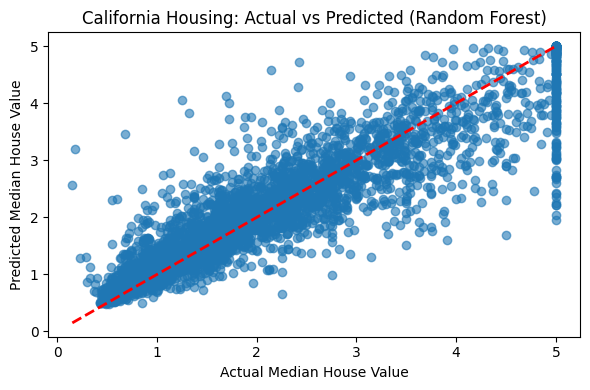

In [10]:
# Plot Actual vs Predicted values for the best R2 model
best_regression_model = california_results.iloc[0]['Regression Technique']

cal_predictions = {
    'Decision Tree': tree_cal_preds,
    'Random Forest': rf_cal_preds,
    'Voting Regressor': voting_cal_preds,
    'AdaBoost': ada_cal_preds,
    'Gradient Boosting': gb_cal_preds
}

best_cal_preds = cal_predictions[best_regression_model]

plt.figure(figsize=(6, 4))
plt.scatter(y_test_cal, best_cal_preds, alpha=0.6)
plt.plot(
    [y_test_cal.min(), y_test_cal.max()],
    [y_test_cal.min(), y_test_cal.max()],
    'r--',
    lw=2
)
plt.title(f"California Housing: Actual vs Predicted ({best_regression_model})")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.tight_layout()
plt.show()


## Conclusion

- The Titanic dataset was used for a binary classification task.
- Decision Tree, Random Forest, Voting, AdaBoost and Gradient Boosting classifiers were trained and compared.
- The California Housing dataset was used for a regression task.
- Decision Tree, Random Forest, Voting, AdaBoost and Gradient Boosting regressors were evaluated using MSE, RMSE and R².
- The comparison tables identify the best-performing model for each task based on the corresponding evaluation metric.
